In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
cnn_results = pd.read_csv("../results/metrics/task1_cnn_results.csv")
lstm_results = pd.read_csv("../results/metrics/task1_lstm_results.csv")

comparison = pd.concat(
    [cnn_results, lstm_results],
    ignore_index=True
)

comparison

,Task,Model,RMSE,MAE
0,Task 1.1 - Next-day prediction,CNN,0.024287,0.016860
1,Task 1.2 - 7th day prediction,CNN,0.096379,0.071221
2,Task 1.3 - Next 7 days prediction,CNN,0.057226,0.039113
3,Task 1.2 - 7th day prediction,LSTM,0.185752,0.134104
4,Task 1.3 - Next 7 days prediction,LSTM,0.181437,0.123582


In [3]:
comparison_rounded = comparison.copy()

comparison_rounded["RMSE"] = comparison_rounded["RMSE"].round(4)
comparison_rounded["MAE"] = comparison_rounded["MAE"].round(4)

comparison_rounded

,Task,Model,RMSE,MAE
0,Task 1.1 - Next-day prediction,CNN,0.0243,0.0169
1,Task 1.2 - 7th day prediction,CNN,0.0964,0.0712
2,Task 1.3 - Next 7 days prediction,CNN,0.0572,0.0391
3,Task 1.2 - 7th day prediction,LSTM,0.1858,0.1341
4,Task 1.3 - Next 7 days prediction,LSTM,0.1814,0.1236


In [4]:
comparison.to_csv(
    "../results/metrics/task1_model_comparison.csv",
    index=False
)

comparison_rounded.to_csv(
    "../results/tables/task1_model_comparison_table.csv",
    index=False
)

print("Task 1 model comparison saved successfully.")

Task 1 model comparison saved successfully.


In [5]:
best_models = comparison.loc[
    comparison.groupby("Task")["RMSE"].idxmin()
].reset_index(drop=True)

best_models_rounded = best_models.copy()
best_models_rounded["RMSE"] = best_models_rounded["RMSE"].round(4)
best_models_rounded["MAE"] = best_models_rounded["MAE"].round(4)

best_models_rounded

,Task,Model,RMSE,MAE
0,Task 1.1 - Next-day prediction,CNN,0.0243,0.0169
1,Task 1.2 - 7th day prediction,CNN,0.0964,0.0712
2,Task 1.3 - Next 7 days prediction,CNN,0.0572,0.0391


In [6]:
best_models.to_csv(
    "../results/metrics/task1_best_models.csv",
    index=False
)

best_models_rounded.to_csv(
    "../results/tables/task1_best_models_table.csv",
    index=False
)

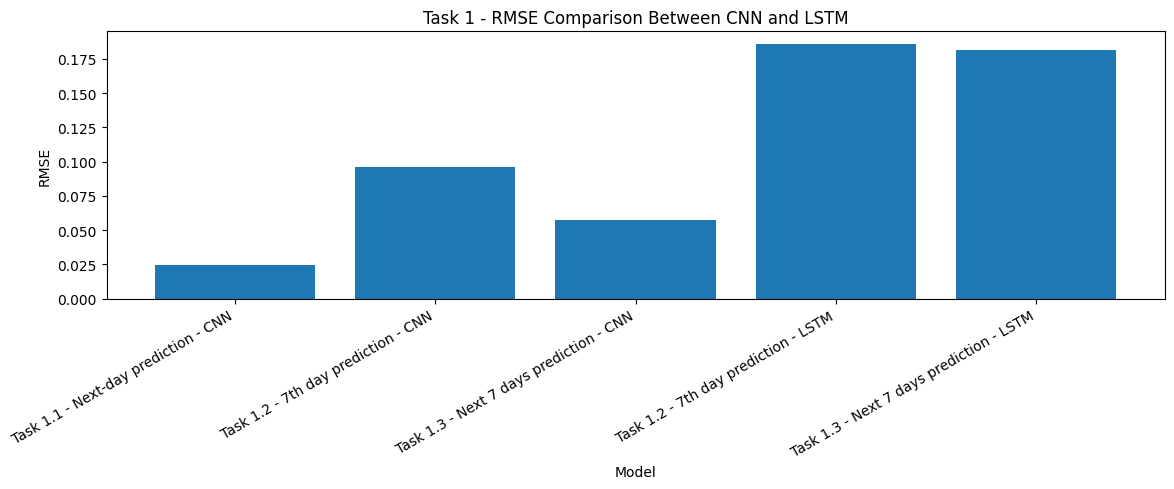

In [7]:
plt.figure(figsize=(12, 5))

labels = comparison["Task"] + " - " + comparison["Model"]

plt.bar(
    labels,
    comparison["RMSE"]
)

plt.title("Task 1 - RMSE Comparison Between CNN and LSTM")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "../results/figures/task1_rmse_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

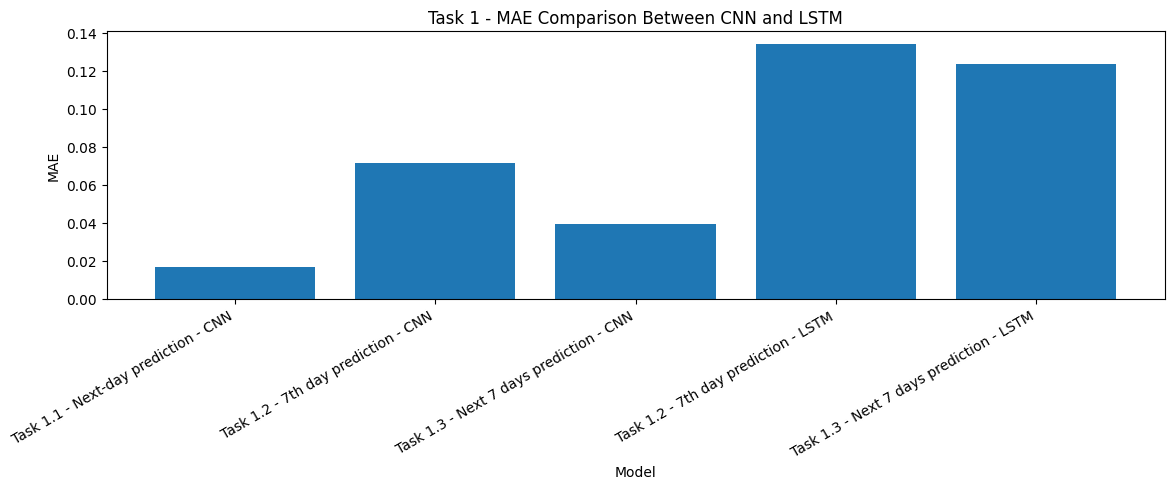

In [8]:
plt.figure(figsize=(12, 5))

labels = comparison["Task"] + " - " + comparison["Model"]

plt.bar(
    labels,
    comparison["MAE"]
)

plt.title("Task 1 - MAE Comparison Between CNN and LSTM")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "../results/figures/task1_mae_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()